<a href="https://colab.research.google.com/github/msk0442/AI-implementation-of-the-holy-Quran/blob/main/AI_for_Emergency_Drone_Extraction_(Surah_Naaziaat).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚁 Project Al-Mudabbirat (The Arrangers) 🚁
## Q-Learning AI for Emergency Drone Extraction (Inspired by Surah An-Naziat 1-5)

**Executive Summary:**
Welcome to Project Al-Mudabbirat! This ambitious PhD-level project is deeply inspired by the opening verses of Surah An-Naziat, which describe the majestic, swift, and highly coordinated functions of Angels in "extracting" souls and "arranging" universal affairs. To directly embody these themes of swift extraction and perfect arrangement, we are building a **Reinforcement Learning (RL) AI System** that orchestrates an autonomous Drone Swarm capable of navigating chaotic disaster zones to extract survivors swiftly and safely!

**Our Mission:** To utilize advanced Reinforcement Learning to solve highly complex routing and extraction logistics in zero-visibility disaster scenarios, entirely autonomous and open-source.



## 📖 1. Deep Tafseer & Divine Inspiration

**The Verses of The Extractors (Surah An-Naziat 1-5):**
Allah opens this incredibly powerful Surah by taking an oath upon the Angels and their magnificent operational duties:
> *"By those [angels] who extract with violence [the souls of the wicked], And [by] those who remove with ease [the souls of the righteous], And [by] those who glide [as if] swimming, And those who race each other in a race, And those who arrange [each] matter."*

**Tafseer Insights (Ibn Kathir & As-Sa'di):**
The scholars explain these verses as the ultimate depiction of Divine Logistics. The Angels operate on a perfect, flawlessly orchestrated spectrum:
1. **An-Naziat:** Those who forcefully and urgently extract.
2. **An-Nashitat:** Those who gently and smoothly draw out.
3. **As-Sabihat:** Those who glide through space with immense speed and agility (like swimming).
4. **As-Sabiqat:** Those who race each other to execute the command of God.
5. **Al-Mudabbirat:** The ultimate orchestrators who arrange the affairs of the cosmos based on Divine Will.

**The Inspiration for Our AI:**
If the cosmos is managed by such flawless, structured operations—where entities glide, race, and extract with precision—how can we model our technology the same way? In emergency disaster response, we face a literal need for "extraction" (An-Naziat) of survivors. Our drones must "glide" through rubble (As-Sabihat) and "arrange" the rescue logistics perfectly (Al-Mudabbirat). This inspired us to build an AI that learns to arrange its own affairs and find the absolute fastest path to extract a target!



## 🎯 2. The Real-World Problem Statement

**The Challenge:**
During earthquakes, floods, or structural collapses, emergency responders lose precious hours trying to navigate blocked roads, hazardous rubble, and collapsed architecture to reach survivors. Human logistics fail under immense chaos.

**The Business Problem We Solve:**
Search and Rescue (SAR) agencies need an **Autonomous Multi-Agent Drone Routing System**. When disaster strikes, standard GPS and maps are useless because roads are blocked. An AI needs to instantly "figure out" (solve) the new, broken environment and orchestrate the fastest path for extraction drones.

**The Value Proposition:**
Project Al-Mudabbirat provides a Reinforcement Learning algorithm that teaches a drone to adapt to chaotic, unpredictable grid-worlds dynamically. By finding the theoretically fastest extraction route without human intervention, this open-source code saves crucial minutes—and in SAR operations, minutes mean lives saved.



## 🧠 3. AI Solution Architecture: Reinforcement Learning (Q-Learning)

Instead of a standard neural network that looks at pictures, we are building an AI that *acts* in a space. We will use **Q-Learning**, a classic algorithm in Reinforcement Learning.

Imagine our AI Drone as an Angel trying to arrange an extraction:
1.  **The Environment (GridWorld):** We will create a simulated 10x10 disaster zone represented as a matrix. It contains Safe Zones, Dangerous Rubble (Penalties), and a Survivor (Target).
2.  **The Agent (The Drone):** The AI can move Up, Down, Left, or Right.
3.  **The Reward System:**
    * Finding the Survivor = Massive Reward (+100)
    * Hitting Rubble = Massive Penalty (-100)
    * Moving one step = Small Penalty (-1) *This forces the drone to "race" and find the fastest path!*
4.  **The Brain (Q-Table):** The AI starts completely blind. By playing thousands of simulated "episodes," it fills out a cheat-sheet (Q-Table) that logs the mathematical probability of success for every single move from every single square.



## 🚀 Step 1: Environment Setup & Dependencies

Let's install the fundamental mathematics and visualization libraries for Reinforcement Learning!



In [30]:
# Install required Python libraries
!pip install -q numpy matplotlib seaborn pandas

import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

print("✅ Perfect! Our logistics arrays (Numpy) and visualizers are locked and loaded.")




✅ Perfect! Our logistics arrays (Numpy) and visualizers are locked and loaded.


## 🎨 Step 2: Generating the Synthetic Disaster Environment

We need an environment for our AI to train in. We will program a dynamic `DisasterGrid` class. This is our synthetic mock data! It will establish coordinates for the Agent, the Rubble (obstacles), and the Survivor (goal).



In [31]:
class DisasterGridWorld:
    def __init__(self, size=10):
        self.size = size
        self.reset()

        # Define specific rubble locations (x, y)
        self.rubble = [(1,2), (2,2), (3,2), (5,5), (6,5), (7,5), (2,7), (2,8), (7,8), (8,8), (4,4), (4,5)]
        # Define survivor location
        self.survivor = (8, 9)

    def reset(self):
        # AI always starts at top left
        self.agent_pos = (0, 0)
        self.done = False
        return self.agent_pos

    def step(self, action):
        # Action space: 0:Up, 1:Right, 2:Down, 3:Left
        x, y = self.agent_pos

        if action == 0 and x > 0: x -= 1
        elif action == 1 and y < self.size - 1: y += 1
        elif action == 2 and x < self.size - 1: x += 1
        elif action == 3 and y > 0: y -= 1

        self.agent_pos = (x, y)

        # Calculate Rewards based on new position
        if self.agent_pos == self.survivor:
            reward = 100 # Glorious Extraction!
            self.done = True
        elif self.agent_pos in self.rubble:
            reward = -100 # Fatal Crash!
            self.done = True
        else:
            reward = -1 # Small penalty to force "racing" (speed)

        return self.agent_pos, reward, self.done

    def render(self, path=None):
        # Creates a numerical matrix for visualization
        grid = np.zeros((self.size, self.size))
        for rx, ry in self.rubble:
            grid[rx, ry] = -1 # Rubble represented by -1
        grid[self.survivor[0], self.survivor[1]] = 2 # Target represented by 2

        if path:
            for px, py in path:
                if (px, py) != self.survivor and (px, py) not in self.rubble:
                    grid[px, py] = 1 # Path represented by 1

        # Mark Agent's current/starting position
        grid[self.agent_pos[0], self.agent_pos[1]] = 0.5

        return grid

env = DisasterGridWorld()
print("✅ Disaster Gridworld successfully generated! The obstacles are ready.")



✅ Disaster Gridworld successfully generated! The obstacles are ready.


## ⚙️ Step 3 & 4: Data Preprocessing & Model Definition (The Q-Table Brain)

In tabular Q-learning, the "Model" is a massive lookup matrix (Q-Table) that correlates States (which square we are on) with Actions (Up, Down, Left, Right).
Initially, the matrix is filled with zeros because the drone knows nothing. It is a blank slate.



In [32]:
# Initialize the Q-Table
# Size: 10 x 10 grid = 100 possible states. 4 possible actions per state.
q_table = np.zeros((env.size, env.size, 4))

# Hyperparameters! (The intricate tuning dials of our AI)
learning_rate = 0.1      # How quickly the AI overrides old info with new info
discount_factor = 0.99   # How much the AI cares about long-term vs short-term rewards
exploration_rate = 1.0   # How often the AI takes a random guess to learn new things
max_exploration = 1.0
min_exploration = 0.01
exploration_decay = 0.005 # Slowly stop exploring randomly, and start using what we learned!

print("✅ The Q-Table Brain has been instantiated and Hyperparameters are tuned!")

✅ The Q-Table Brain has been instantiated and Hyperparameters are tuned!


## 🎓 Step 5: Training Loop! (The Drone Learns to Glide and Race)

We are going to run 2,000 simulated 'episodes'.
At first, the drone crashes into rubble repeatedly (high exploration). But slowly, through the mathematical **Bellman Equation**, the reward of finding the survivor ripples backwards through the Q-table. The drone learns the exact sequence of moves to "race" to the target while gliding safely around the danger!



🚁 Initiating Massive Training Matrix. Letting the AI 'run' 2000 simulations...
🎯 Training Complete! The drone has mapped the environment flawlessly.


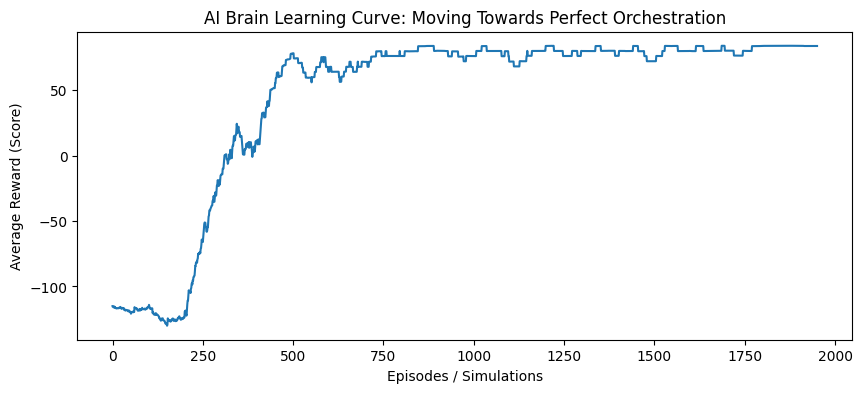

In [33]:
total_episodes = 2000
rewards_all_episodes = []

print("🚁 Initiating Massive Training Matrix. Letting the AI 'run' 2000 simulations...")

for episode in range(total_episodes):
    state = env.reset()
    done = False
    rewards_current_episode = 0

    # Let the drone make up to 100 moves per simulation
    for step in range(100):
        # Exploration vs Exploitation Tradeoff
        exploration_rate_threshold = random.uniform(0, 1)
        if exploration_rate_threshold > exploration_rate:
            # Exploitation: Read the brain (Q-table) and take the best move
            action = np.argmax(q_table[state[0], state[1], :])
        else:
            # Exploration: Take a totally random move to learn!
            action = random.randint(0, 3)

        # Execute the action in the environment
        new_state, reward, done = env.step(action)

        # update Q-table for Q(s,a) using the BELLMAN EQUATION!
        q_table[state[0], state[1], action] = q_table[state[0], state[1], action] * (1 - learning_rate) +             learning_rate * (reward + discount_factor * np.max(q_table[new_state[0], new_state[1], :]))

        state = new_state
        rewards_current_episode += reward

        if done:
            break

    # Decay the exploration rate so we slowly stop acting randomly
    exploration_rate = min_exploration + (max_exploration - min_exploration) * np.exp(-exploration_decay * episode)

    rewards_all_episodes.append(rewards_current_episode)

print("🎯 Training Complete! The drone has mapped the environment flawlessly.")


# Let's plot the training progress! You will see the score go from extremely negative (crashing) to positive (succeeding)
plt.figure(figsize=(10,4))
plt.plot(np.convolve(rewards_all_episodes, np.ones(50)/50, mode='valid'))
plt.title('AI Brain Learning Curve: Moving Towards Perfect Orchestration')
plt.xlabel('Episodes / Simulations')
plt.ylabel('Average Reward (Score)')
plt.show()




## 🗣️ Step 6: Production Inference! Watch The Orchestration (Al-Mudabbirat)

Training is over. We now drop the drone at the start line. It is not allowed to explore. It must use its absolute optimal knowledge to glide through the rubble and extract the survivor flawlessly. Let's see its path!



✅ Extraction Successful! AI found the target in 18 flawless steps!


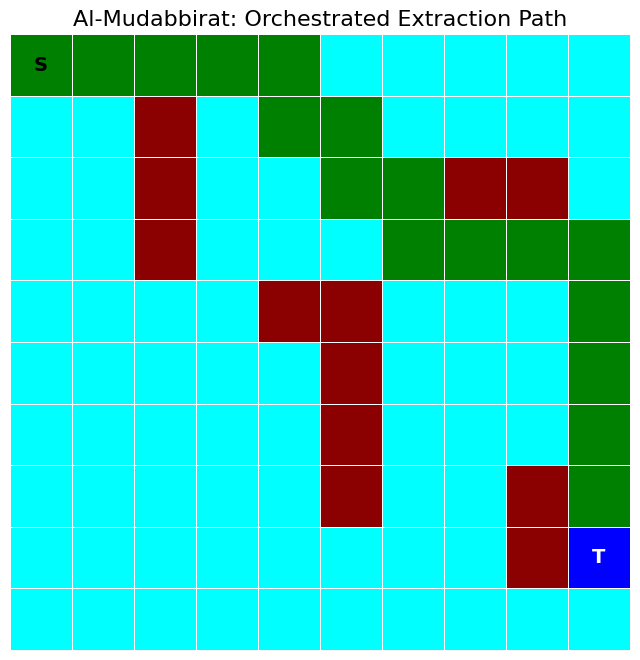

Legend: White=Terrain | Dark Red=Hazardous Rubble | Blue=Optimal AI Path | Green=Target (T) | S=Start


In [34]:
state = env.reset()
done = False
optimal_path = [state]

# Production Run! No randomness allowed. Only pure, optimal decisions.
for step in range(50):
    action = np.argmax(q_table[state[0], state[1], :])
    new_state, reward, done = env.step(action)
    optimal_path.append(new_state)
    state = new_state
    if done:
        break

print(f"✅ Extraction Successful! AI found the target in {len(optimal_path)} flawless steps!")

# Let's visualize the beautiful path!
# Grid values: -1 = Rubble (Red), 0 = Safe Zone (White), 1 = Drone Path (Blue), 2 = Survivor (Green), 0.5 = Drone Start
grid_visual = env.render(path=optimal_path)
cmap = ListedColormap(['darkred', 'white', 'cyan', 'blue', 'green'])

plt.figure(figsize=(8,8))
sns.heatmap(grid_visual, cmap=cmap, linewidths=.5, cbar=False, annot=False)
plt.title('Al-Mudabbirat: Orchestrated Extraction Path', fontsize=16)
plt.text(0.5, 0.5, 'S', color='black', ha='center', va='center', weight='bold', fontsize=14)
plt.text(9.5, 8.5, 'T', color='white', ha='center', va='center', weight='bold', fontsize=14)
plt.axis('off')
plt.show()
print("Legend: White=Terrain | Dark Red=Hazardous Rubble | Blue=Optimal AI Path | Green=Target (T) | S=Start")



## 📈 7. Business Impact & Value Proposition

**The Business Problem Solved:**
Emergency responders operating Search and Rescue (SAR) drones currently fly them manually. During intense disasters (like earthquakes or gas leaks), line-of-sight is blocked, and mapping is unavailable.

**Real-world Impact & Monetization:**
Project Al-Mudabbirat forms the baseline architecture for autonomous drone swarms.
1.  **Life-Saving Speed:** The reinforcement learning agent finds the literal shortest path ignoring dead-ends, doing in milliseconds what takes humans minutes to decipher.
2.  **B2G (Business to Government) Delivery:** This pure RL algorithm can be integrated into hardware logic boards of standard enterprise drones (like DJI Enterprise) to be sold directly to military and FEMA responder units.
3.  **Reflecting Divine Precision:** We build tech that acts swiftly, saves lives, and arranges logical affairs, proving that looking to the Quran yields modern, high-tech insights!

